In [ ]:
!nvidia-smi

Sat May  9 12:45:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q "pandas==2.2.2" transformers datasets evaluate accelerate scikit-learn matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 104.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import transformers
import datasets
import evaluate
import sklearn
import torch

print("pandas:", pd.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

pandas: 2.2.2
transformers: 5.8.0
datasets: 4.8.5
evaluate: 0.4.6
torch: 2.10.0+cu128
cuda available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/COMP6258_AuroRA_Reproduction"

folders = [
    PROJECT_DIR,
    f"{PROJECT_DIR}/results",
    f"{PROJECT_DIR}/figures",
    f"{PROJECT_DIR}/checkpoints",
    f"{PROJECT_DIR}/notebooks",
    f"{PROJECT_DIR}/report"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folder created:")
print(PROJECT_DIR)

Project folder created:
/content/drive/MyDrive/COMP6258_AuroRA_Reproduction


In [ ]:
import os
import time
import random
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
class CubicBSplineLayer(nn.Module):
    def __init__(self, hidden_dim, num_basis=8, grid_min=-3.0, grid_max=3.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_basis = num_basis

        centers = torch.linspace(grid_min, grid_max, num_basis)
        self.register_buffer("centers", centers)

        self.step = (grid_max - grid_min) / (num_basis - 1)

        self.coeff = nn.Parameter(torch.zeros(hidden_dim, num_basis))
        nn.init.normal_(self.coeff, mean=0.0, std=0.02)

    def cubic_basis(self, z):
        u = torch.abs((z.unsqueeze(-1) - self.centers) / self.step)

        inner = (2.0 / 3.0) - u**2 + 0.5 * u**3
        outer = ((2.0 - u) ** 3) / 6.0

        basis = torch.where(
            u < 1.0,
            inner,
            torch.where(u < 2.0, outer, torch.zeros_like(u))
        )

        return basis

    def forward(self, z):
        basis = self.cubic_basis(z)

        coeff_shape = [1] * (z.dim() - 1) + [self.hidden_dim, self.num_basis]
        coeff = self.coeff.view(*coeff_shape)

        out = (basis * coeff).sum(dim=-1)
        return out


class ANLLayer(nn.Module):
    def __init__(
        self,
        hidden_dim,
        use_fixed=True,
        use_spline=True,
        activation="tanh",
        num_basis=8
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.use_fixed = use_fixed
        self.use_spline = use_spline
        self.activation = activation

        self.H = nn.Linear(hidden_dim, hidden_dim, bias=False)
        nn.init.eye_(self.H.weight)

        self.spline = CubicBSplineLayer(
            hidden_dim=hidden_dim,
            num_basis=num_basis
        )

    def fixed_activation(self, z):
        if self.activation == "tanh":
            return torch.tanh(z)
        elif self.activation == "sigmoid":
            return torch.sigmoid(z)
        elif self.activation == "leaky_relu":
            return torch.nn.functional.leaky_relu(z, negative_slope=0.01)
        else:
            raise ValueError(f"Unknown activation: {self.activation}")

    def forward(self, z):
        out = 0.0

        if self.use_fixed:
            out = out + self.fixed_activation(self.H(self.fixed_activation(z)))

        if self.use_spline:
            out = out + self.spline(z)

        return out


class LoRALinear(nn.Module):
    def __init__(self, base_layer: nn.Linear, rank=2, alpha=4, dropout=0.0):
        super().__init__()

        self.base = base_layer
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features
        self.rank = rank
        self.scaling = alpha / rank

        self.base.weight.requires_grad = False
        if self.base.bias is not None:
            self.base.bias.requires_grad = False

        self.dropout = nn.Dropout(dropout)

        self.A = nn.Linear(self.in_features, rank, bias=False)
        self.B = nn.Linear(rank, self.out_features, bias=False)

        nn.init.normal_(self.A.weight, mean=0.0, std=1.0 / rank)
        nn.init.zeros_(self.B.weight)

    def forward(self, x):
        lora_update = self.B(self.A(self.dropout(x))) * self.scaling
        return self.base(x) + lora_update


class AuroRALinear(nn.Module):
    def __init__(
        self,
        base_layer: nn.Linear,
        rank=2,
        alpha=4,
        dropout=0.0,
        use_fixed=True,
        use_spline=True,
        activation="tanh",
        num_basis=8
    ):
        super().__init__()

        self.base = base_layer
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features
        self.rank = rank
        self.scaling = alpha / rank

        self.base.weight.requires_grad = False
        if self.base.bias is not None:
            self.base.bias.requires_grad = False

        self.dropout = nn.Dropout(dropout)

        self.A = nn.Linear(self.in_features, rank, bias=False)
        self.anl = ANLLayer(
            hidden_dim=rank,
            use_fixed=use_fixed,
            use_spline=use_spline,
            activation=activation,
            num_basis=num_basis
        )
        self.B = nn.Linear(rank, self.out_features, bias=False)

        nn.init.normal_(self.A.weight, mean=0.0, std=1.0 / rank)
        nn.init.zeros_(self.B.weight)

    def forward(self, x):
        z = self.A(self.dropout(x))
        z = self.anl(z)
        aurora_update = self.B(z) * self.scaling
        return self.base(x) + aurora_update

In [ ]:
def inject_adapter(
    model,
    target_modules,
    method="aurora",
    rank=2,
    alpha=4,
    dropout=0.0,
    use_fixed=True,
    use_spline=True,
    activation="tanh",
    num_basis=8
):
    replaced = 0

    for child_name, child_module in model.named_children():

        should_replace = (
            isinstance(child_module, nn.Linear)
            and child_name in target_modules
        )

        if should_replace:
            if method == "lora":
                new_module = LoRALinear(
                    child_module,
                    rank=rank,
                    alpha=alpha,
                    dropout=dropout
                )
            elif method == "aurora":
                new_module = AuroRALinear(
                    child_module,
                    rank=rank,
                    alpha=alpha,
                    dropout=dropout,
                    use_fixed=use_fixed,
                    use_spline=use_spline,
                    activation=activation,
                    num_basis=num_basis
                )
            else:
                raise ValueError(f"Unknown method: {method}")

            setattr(model, child_name, new_module)
            replaced += 1

        else:
            replaced += inject_adapter(
                child_module,
                target_modules=target_modules,
                method=method,
                rank=rank,
                alpha=alpha,
                dropout=dropout,
                use_fixed=use_fixed,
                use_spline=use_spline,
                activation=activation,
                num_basis=num_basis
            )

    return replaced


def freeze_all_params(model):
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_classifier(model):
    for param in model.classifier.parameters():
        param.requires_grad = True


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def print_trainable_parameters(model):
    trainable, total = count_parameters(model)
    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    print(f"Trainable percent:    {100 * trainable / total:.4f}%")

In [ ]:
test_linear = nn.Linear(768, 768)
test_x = torch.randn(2, 16, 768)

test_layer = AuroRALinear(
    base_layer=test_linear,
    rank=2,
    alpha=4,
    use_fixed=True,
    use_spline=True,
    activation="tanh"
)

test_out = test_layer(test_x)

print("Input shape: ", test_x.shape)
print("Output shape:", test_out.shape)

Input shape:  torch.Size([2, 16, 768])
Output shape: torch.Size([2, 16, 768])


In [ ]:
TASK_TO_KEYS = {
    "cola": ("sentence", None),
    "mrpc": ("sentence1", "sentence2"),
    "rte": ("sentence1", "sentence2"),
}

def prepare_glue_dataset(task_name, tokenizer, max_length=512):
    raw_dataset = load_dataset("glue", task_name)

    sentence1_key, sentence2_key = TASK_TO_KEYS[task_name]

    def preprocess_function(examples):
        if sentence2_key is None:
            return tokenizer(
                examples[sentence1_key],
                truncation=True,
                padding="max_length",
                max_length=max_length
            )
        else:
            return tokenizer(
                examples[sentence1_key],
                examples[sentence2_key],
                truncation=True,
                padding="max_length",
                max_length=max_length
            )

    encoded_dataset = raw_dataset.map(preprocess_function, batched=True)

    encoded_dataset = encoded_dataset.rename_column("label", "labels")

    encoded_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    return encoded_dataset


def build_compute_metrics(task_name):
    metric = evaluate.load("glue", task_name)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)

        result = metric.compute(
            predictions=preds,
            references=labels
        )

        if task_name == "cola":
            result["main_score"] = result["matthews_correlation"]
        elif task_name == "mrpc":
            result["main_score"] = result["accuracy"]
        elif task_name == "rte":
            result["main_score"] = result["accuracy"]
        else:
            raise ValueError(f"Unsupported task: {task_name}")

        return result

    return compute_metrics

In [ ]:
def make_training_args(
    output_dir,
    learning_rate,
    batch_size,
    epochs,
    seed
):
    base_kwargs = dict(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.0,
        warmup_ratio=0.06,
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        seed=seed,
        fp16=torch.cuda.is_available(),
    )

    signature = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in signature.parameters:
        base_kwargs["eval_strategy"] = "epoch"
    else:
        base_kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**base_kwargs)


def train_one_run(
    task_name,
    method,
    rank,
    seed,
    epochs,
    lr,
    batch_size,
    max_length,
    alpha=4,
    dropout=0.0,
    use_fixed=True,
    use_spline=True,
    activation="tanh",
    num_basis=8,
    project_dir=PROJECT_DIR
):

    print("=" * 80)
    print("Starting run")
    print("task:", task_name)
    print("method:", method)
    print("rank:", rank)
    print("seed:", seed)
    print("epochs:", epochs)
    print("lr:", lr)
    print("=" * 80)

    set_seed(seed)

    tokenizer = AutoTokenizer.from_pretrained("roberta-base", use_fast=True)
    dataset = prepare_glue_dataset(task_name, tokenizer, max_length=max_length)

    num_labels = dataset["train"].features["labels"].num_classes

    model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=num_labels
    )

    freeze_all_params(model)

    unfreeze_classifier(model)

    replaced_layers = inject_adapter(
        model=model,
        target_modules=["query", "value"],
        method=method,
        rank=rank,
        alpha=alpha,
        dropout=dropout,
        use_fixed=use_fixed,
        use_spline=use_spline,
        activation=activation,
        num_basis=num_basis
    )

    print("Replaced linear layers:", replaced_layers)
    print_trainable_parameters(model)

    run_name = (
        f"{task_name}_{method}_r{rank}_seed{seed}"
        f"_fixed{int(use_fixed)}_spline{int(use_spline)}_{activation}"
    )

    output_dir = f"{project_dir}/checkpoints/{run_name}"

    training_args = make_training_args(
        output_dir=output_dir,
        learning_rate=lr,
        batch_size=batch_size,
        epochs=epochs,
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        compute_metrics=build_compute_metrics(task_name),
    )

    start_time = time.time()

    trainer.train()
    eval_result = trainer.evaluate()

    elapsed_min = (time.time() - start_time) / 60

    trainable_params, total_params = count_parameters(model)

    row = {
        "task": task_name,
        "method": method,
        "rank": rank,
        "seed": seed,
        "epochs": epochs,
        "lr": lr,
        "batch_size": batch_size,
        "max_length": max_length,
        "alpha": alpha,
        "dropout": dropout,
        "use_fixed": use_fixed,
        "use_spline": use_spline,
        "activation": activation,
        "num_basis": num_basis,
        "replaced_layers": replaced_layers,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "trainable_percent": 100 * trainable_params / total_params,
        "time_min": elapsed_min,
    }

    row.update(eval_result)

    results_path = f"{project_dir}/results/results_raw.csv"

    if os.path.exists(results_path):
        old_df = pd.read_csv(results_path)
        new_df = pd.concat([old_df, pd.DataFrame([row])], ignore_index=True)
    else:
        new_df = pd.DataFrame([row])

    new_df.to_csv(results_path, index=False)

    print("Finished run")
    print("Saved to:", results_path)
    print(row)

    return row

In [ ]:
CONFIG_FAST = {
    "mrpc": {
        "epochs": 3,
        "lr": 8e-4,
        "batch_size": 32,
        "max_length": 256,
    },
    "rte": {
        "epochs": 3,
        "lr": 5e-4,
        "batch_size": 16,
        "max_length": 256,
    },
    "cola": {
        "epochs": 3,
        "lr": 5e-3,
        "batch_size": 32,
        "max_length": 256,
    },
}

CONFIG_REPORT = {
    "mrpc": {
        "epochs": 10,
        "lr": 8e-4,
        "batch_size": 32,
        "max_length": 256,
    },
    "rte": {
        "epochs": 15,
        "lr": 5e-4,
        "batch_size": 16,
        "max_length": 256,
    },
    "cola": {
        "epochs": 15,
        "lr": 5e-3,
        "batch_size": 32,
        "max_length": 256,
    },
}

CONFIG_PAPER_LIKE = {
    "mrpc": {
        "epochs": 30,
        "lr": 8e-4,
        "batch_size": 64,
        "max_length": 512,
    },
    "rte": {
        "epochs": 80,
        "lr": 5e-4,
        "batch_size": 16,
        "max_length": 512,
    },
    "cola": {
        "epochs": 90,
        "lr": 5e-3,
        "batch_size": 32,
        "max_length": 512,
    },
}

In [ ]:
cfg = CONFIG_PAPER_LIKE["mrpc"]

debug_lora = train_one_run(
    task_name="mrpc",
    method="lora",
    rank=2,
    seed=0,
    epochs=cfg["epochs"],
    lr=cfg["lr"],
    batch_size=cfg["batch_size"],
    max_length=cfg["max_length"],
    use_fixed=False,
    use_spline=False,
    activation="tanh",
)

debug_aurora = train_one_run(
    task_name="mrpc",
    method="aurora",
    rank=2,
    seed=0,
    epochs=cfg["epochs"],
    lr=cfg["lr"],
    batch_size=cfg["batch_size"],
    max_length=cfg["max_length"],
    use_fixed=True,
    use_spline=True,
    activation="tanh",
)

Starting run
task: mrpc
method: lora
rank: 2
seed: 0
epochs: 30
lr: 0.0008


Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 666,338
Total parameters:     124,721,378
Trainable percent:    0.5343%


Epoch,Training Loss,Validation Loss,Accuracy,F1,Main Score
1,0.649010,0.613803,0.683824,0.812227,0.683824
2,0.585935,0.503569,0.769608,0.841216,0.769608
3,0.497757,0.469718,0.759804,0.845912,0.759804
4,0.423522,0.368461,0.830882,0.875226,0.830882
5,0.374884,0.367573,0.830882,0.884422,0.830882
6,0.371192,0.373341,0.833333,0.887417,0.833333
7,0.350874,0.389023,0.835784,0.889984,0.835784
8,0.328554,0.325844,0.867647,0.907534,0.867647
9,0.324434,0.307516,0.865196,0.899083,0.865196
10,0.317403,0.299225,0.875000,0.907441,0.875000


Training Loss,Validation Loss,Epoch,Accuracy,F1,Main Score
0.204766,0.350324,30,0.877451,0.911032,0.877451


Finished run
Saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_raw.csv
{'task': 'mrpc', 'method': 'aurora', 'rank': 2, 'seed': 0, 'epochs': 30, 'lr': 0.0008, 'batch_size': 64, 'max_length': 512, 'alpha': 4, 'dropout': 0.0, 'use_fixed': True, 'use_spline': True, 'activation': 'tanh', 'num_basis': 8, 'replaced_layers': 24, 'trainable_params': 666338, 'total_params': 124721378, 'trainable_percent': 0.5342612555162757, 'time_min': 24.224304763476052, 'eval_loss': 0.3503236472606659, 'eval_accuracy': 0.8774509803921569, 'eval_f1': 0.9110320284697508, 'eval_main_score': 0.8774509803921569}


In [ ]:
df = pd.read_csv(f"{PROJECT_DIR}/results/results_raw.csv")
df.tail()

,task,method,rank,seed,epochs,lr,batch_size,max_length,alpha,dropout,...,num_basis,replaced_layers,trainable_params,total_params,trainable_percent,time_min,eval_loss,eval_accuracy,eval_f1,eval_main_score
0,mrpc,lora,2,0,3,0.0008,32,256,4,0.0,...,8,24,665858,124720898,0.533878,0.961757,0.603644,0.713235,0.825112,0.713235
1,mrpc,aurora,2,0,3,0.0008,32,256,4,0.0,...,8,24,666338,124721378,0.534261,1.005455,0.400351,0.818627,0.875421,0.818627
2,mrpc,lora,2,0,30,0.0008,64,512,4,0.0,...,8,24,665858,124720898,0.533878,23.938115,0.718392,0.857843,0.899306,0.857843
3,mrpc,aurora,2,0,30,0.0008,64,512,4,0.0,...,8,24,666338,124721378,0.534261,24.224305,0.350324,0.877451,0.911032,0.877451


In [ ]:
MAIN_EXPERIMENTS = [
    {
        "label": "LoRA rank 2",
        "method": "lora",
        "rank": 2,
        "use_fixed": False,
        "use_spline": False,
        "activation": "tanh",
    },
    {
        "label": "LoRA rank 8",
        "method": "lora",
        "rank": 8,
        "use_fixed": False,
        "use_spline": False,
        "activation": "tanh",
    },
    {
        "label": "AuroRA rank 2",
        "method": "aurora",
        "rank": 2,
        "use_fixed": True,
        "use_spline": True,
        "activation": "tanh",
    },
]

TASKS = ["mrpc", "rte", "cola"]

SEEDS_MAIN = [0]

for task_name in TASKS:
    cfg = CONFIG_REPORT[task_name]

    for exp in MAIN_EXPERIMENTS:
        for seed in SEEDS_MAIN:
            train_one_run(
                task_name=task_name,
                method=exp["method"],
                rank=exp["rank"],
                seed=seed,
                epochs=cfg["epochs"],
                lr=cfg["lr"],
                batch_size=cfg["batch_size"],
                max_length=cfg["max_length"],
                use_fixed=exp["use_fixed"],
                use_spline=exp["use_spline"],
                activation=exp["activation"],
            )

Starting run
task: mrpc
method: lora
rank: 2
seed: 0
epochs: 10
lr: 0.0008


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 665,858
Total parameters:     124,720,898
Trainable percent:    0.5339%


Epoch,Training Loss,Validation Loss,Accuracy,F1,Main Score
1,0.594629,0.397216,0.843137,0.887719,0.843137
2,0.459397,0.341366,0.840686,0.884956,0.840686
3,0.402569,0.297915,0.865196,0.900181,0.865196
4,0.359030,0.354358,0.867647,0.908163,0.867647
5,0.325299,0.330688,0.867647,0.902174,0.867647
6,0.296758,0.302394,0.860294,0.900175,0.860294
7,0.256400,0.373196,0.862745,0.902439,0.862745
8,0.234923,0.377593,0.865196,0.905983,0.865196
9,0.219584,0.358249,0.855392,0.897033,0.855392
10,0.189543,0.373106,0.857843,0.898955,0.857843


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 666,338
Total parameters:     124,721,378
Trainable percent:    0.5343%


Epoch,Training Loss,Validation Loss,Matthews Correlation,Main Score
1,0.556808,0.456688,0.542974,0.542974
2,0.484816,0.780895,0.273042,0.273042
3,0.450928,0.728780,0.370195,0.370195
4,0.421388,0.513112,0.536501,0.536501
5,0.405137,0.408829,0.596114,0.596114
6,0.378844,0.609181,0.525469,0.525469
7,0.353825,0.439899,0.613211,0.613211
8,0.335721,0.384811,0.623172,0.623172
9,0.324621,0.476852,0.585483,0.585483
10,0.312178,0.566611,0.545098,0.545098


Training Loss,Validation Loss,Epoch,Matthews Correlation,Main Score
0.242742,0.510448,15,0.600697,0.600697


Finished run
Saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_raw.csv
{'task': 'cola', 'method': 'aurora', 'rank': 2, 'seed': 0, 'epochs': 15, 'lr': 0.005, 'batch_size': 32, 'max_length': 256, 'alpha': 4, 'dropout': 0.0, 'use_fixed': True, 'use_spline': True, 'activation': 'tanh', 'num_basis': 8, 'replaced_layers': 24, 'trainable_params': 666338, 'total_params': 124721378, 'trainable_percent': 0.5342612555162757, 'time_min': 11.633017194271087, 'eval_loss': 0.510448157787323, 'eval_matthews_correlation': 0.6006974680936171, 'eval_main_score': 0.6006974680936171}


In [ ]:
SEEDS_EXTRA = [1, 2]

for task_name in TASKS:
    cfg = CONFIG_REPORT[task_name]

    for exp in MAIN_EXPERIMENTS:
        for seed in SEEDS_EXTRA:
            train_one_run(
                task_name=task_name,
                method=exp["method"],
                rank=exp["rank"],
                seed=seed,
                epochs=cfg["epochs"],
                lr=cfg["lr"],
                batch_size=cfg["batch_size"],
                max_length=cfg["max_length"],
                use_fixed=exp["use_fixed"],
                use_spline=exp["use_spline"],
                activation=exp["activation"],
            )

Starting run
task: mrpc
method: lora
rank: 2
seed: 1
epochs: 10
lr: 0.0008


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 665,858
Total parameters:     124,720,898
Trainable percent:    0.5339%


Epoch,Training Loss,Validation Loss,Accuracy,F1,Main Score
1,0.605691,0.462121,0.762255,0.812379,0.762255
2,0.510832,0.372932,0.833333,0.873134,0.833333
3,0.428107,0.337572,0.843137,0.888889,0.843137
4,0.376333,0.357708,0.852941,0.893617,0.852941
5,0.336455,0.352735,0.862745,0.903780,0.862745
6,0.301419,0.518038,0.848039,0.896321,0.848039
7,0.265266,0.345601,0.867647,0.904594,0.867647
8,0.244731,0.392105,0.855392,0.893694,0.855392
9,0.215135,0.373677,0.872549,0.909408,0.872549
10,0.192007,0.409173,0.865196,0.903678,0.865196


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 666,338
Total parameters:     124,721,378
Trainable percent:    0.5343%


Epoch,Training Loss,Validation Loss,Matthews Correlation,Main Score
1,0.553734,0.966987,0.163322,0.163322
2,0.490463,0.561940,0.491107,0.491107
3,0.446536,0.463908,0.549509,0.549509
4,0.414550,0.405290,0.583594,0.583594
5,0.398337,0.436402,0.555144,0.555144
6,0.370176,0.419248,0.585653,0.585653
7,0.354600,0.409854,0.610018,0.610018
8,0.343572,0.465667,0.537721,0.537721
9,0.316233,0.516134,0.585436,0.585436
10,0.309184,0.442040,0.582907,0.582907


Training Loss,Validation Loss,Epoch,Matthews Correlation,Main Score
0.239507,0.506677,15,0.585706,0.585706


Finished run
Saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_raw.csv
{'task': 'cola', 'method': 'aurora', 'rank': 2, 'seed': 2, 'epochs': 15, 'lr': 0.005, 'batch_size': 32, 'max_length': 256, 'alpha': 4, 'dropout': 0.0, 'use_fixed': True, 'use_spline': True, 'activation': 'tanh', 'num_basis': 8, 'replaced_layers': 24, 'trainable_params': 666338, 'total_params': 124721378, 'trainable_percent': 0.5342612555162757, 'time_min': 11.644310530026754, 'eval_loss': 0.5066773295402527, 'eval_matthews_correlation': 0.5857056435790745, 'eval_main_score': 0.5857056435790745}


In [ ]:
ABLATION_EXPERIMENTS = [
    {
        "label": "AuroRA full",
        "method": "aurora",
        "rank": 2,
        "use_fixed": True,
        "use_spline": True,
        "activation": "tanh",
    },
    {
        "label": "AuroRA without fixed tanh",
        "method": "aurora",
        "rank": 2,
        "use_fixed": False,
        "use_spline": True,
        "activation": "tanh",
    },
    {
        "label": "AuroRA without spline",
        "method": "aurora",
        "rank": 2,
        "use_fixed": True,
        "use_spline": False,
        "activation": "tanh",
    },
]

cfg = CONFIG_REPORT["mrpc"]

for exp in ABLATION_EXPERIMENTS:
    for seed in [0, 1, 2]:
        train_one_run(
            task_name="mrpc",
            method=exp["method"],
            rank=exp["rank"],
            seed=seed,
            epochs=cfg["epochs"],
            lr=cfg["lr"],
            batch_size=cfg["batch_size"],
            max_length=cfg["max_length"],
            use_fixed=exp["use_fixed"],
            use_spline=exp["use_spline"],
            activation=exp["activation"],
        )

Starting run
task: mrpc
method: aurora
rank: 2
seed: 0
epochs: 10
lr: 0.0008


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 666,338
Total parameters:     124,721,378
Trainable percent:    0.5343%


Epoch,Training Loss,Validation Loss,Accuracy,F1,Main Score
1,0.631469,0.589523,0.693627,0.816984,0.693627
2,0.521925,0.430339,0.808824,0.855019,0.808824
3,0.460349,0.425674,0.808824,0.874194,0.808824
4,0.430593,0.362404,0.833333,0.872180,0.833333
5,0.379819,0.339728,0.850490,0.888889,0.850490
6,0.379761,0.360133,0.848039,0.894558,0.848039
7,0.350724,0.340900,0.860294,0.899115,0.860294
8,0.339016,0.351400,0.852941,0.897260,0.852941
9,0.332535,0.325391,0.865196,0.900901,0.865196
10,0.319735,0.326367,0.867647,0.902878,0.867647


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Replaced linear layers: 24
Trainable parameters: 666,338
Total parameters:     124,721,378
Trainable percent:    0.5343%


Epoch,Training Loss,Validation Loss,Accuracy,F1,Main Score
1,0.619793,0.519825,0.759804,0.843949,0.759804
2,0.509451,0.359378,0.821078,0.871705,0.821078
3,0.429119,0.339683,0.845588,0.888889,0.845588
4,0.377720,0.336276,0.843137,0.889273,0.843137
5,0.353689,0.411821,0.848039,0.897010,0.848039
6,0.333864,0.356743,0.838235,0.889632,0.838235
7,0.330840,0.298571,0.862745,0.902098,0.862745
8,0.308312,0.317729,0.852941,0.894366,0.852941
9,0.297982,0.311709,0.860294,0.899824,0.860294
10,0.287130,0.333654,0.870098,0.908778,0.870098


Training Loss,Validation Loss,Epoch,Accuracy,F1,Main Score
0.287130,0.333654,10,0.870098,0.908778,0.870098


Finished run
Saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_raw.csv
{'task': 'mrpc', 'method': 'aurora', 'rank': 2, 'seed': 2, 'epochs': 10, 'lr': 0.0008, 'batch_size': 32, 'max_length': 256, 'alpha': 4, 'dropout': 0.0, 'use_fixed': True, 'use_spline': False, 'activation': 'tanh', 'num_basis': 8, 'replaced_layers': 24, 'trainable_params': 666338, 'total_params': 124721378, 'trainable_percent': 0.5342612555162757, 'time_min': 3.259271204471588, 'eval_loss': 0.33365362882614136, 'eval_accuracy': 0.8700980392156863, 'eval_f1': 0.9087779690189329, 'eval_main_score': 0.8700980392156863}


In [ ]:
raw_path = f"{PROJECT_DIR}/results/results_raw.csv"

df = pd.read_csv(raw_path)

print("Raw result shape:", df.shape)
display(df.tail())

summary = (
    df.groupby([
        "task",
        "method",
        "rank",
        "use_fixed",
        "use_spline",
        "activation"
    ])
    .agg(
        mean_score=("eval_main_score", "mean"),
        std_score=("eval_main_score", "std"),
        mean_trainable_params=("trainable_params", "mean"),
        mean_trainable_percent=("trainable_percent", "mean"),
        mean_time_min=("time_min", "mean"),
        num_runs=("eval_main_score", "count")
    )
    .reset_index()
)

summary_path = f"{PROJECT_DIR}/results/results_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)
display(summary)

Raw result shape: (40, 24)


,task,method,rank,seed,epochs,lr,batch_size,max_length,alpha,dropout,...,replaced_layers,trainable_params,total_params,trainable_percent,time_min,eval_loss,eval_accuracy,eval_f1,eval_main_score,eval_matthews_correlation
35,mrpc,aurora,2,1,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.311365,0.436465,0.769608,0.845395,0.769608,NaN
36,mrpc,aurora,2,2,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.309067,0.476328,0.764706,0.847134,0.764706,NaN
37,mrpc,aurora,2,0,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.262253,0.330129,0.857843,0.896057,0.857843,NaN
38,mrpc,aurora,2,1,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.259131,0.301301,0.870098,0.908146,0.870098,NaN
39,mrpc,aurora,2,2,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.259271,0.333654,0.870098,0.908778,0.870098,NaN


Saved summary to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_summary.csv


,task,method,rank,use_fixed,use_spline,activation,mean_score,std_score,mean_trainable_params,mean_trainable_percent,mean_time_min,num_runs
0,cola,aurora,2,True,True,tanh,0.595676,0.008634,666338.0,0.534261,11.643002,3
1,cola,lora,2,False,False,tanh,0.000000,0.000000,665858.0,0.533878,11.209554,3
2,cola,lora,8,False,False,tanh,0.000000,0.000000,887042.0,0.709963,11.223969,3
3,mrpc,aurora,2,False,True,tanh,0.768791,0.003744,666338.0,0.534261,3.310989,3
4,mrpc,aurora,2,True,False,tanh,0.866013,0.007075,666338.0,0.534261,3.260218,3
5,mrpc,aurora,2,True,True,tanh,0.863358,0.018562,666338.0,0.534261,5.665155,8
6,mrpc,lora,2,False,False,tanh,0.835294,0.068964,665858.0,0.533878,6.905847,5
7,mrpc,lora,8,False,False,tanh,0.883170,0.007488,887042.0,0.709963,3.232170,3
8,rte,aurora,2,True,True,tanh,0.681107,0.036875,666338.0,0.534261,3.680390,3
9,rte,lora,2,False,False,tanh,0.527076,0.093793,665858.0,0.533878,3.074461,3


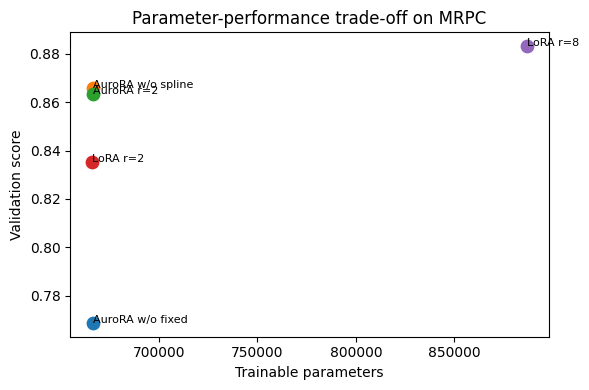

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/mrpc_param_vs_score.png


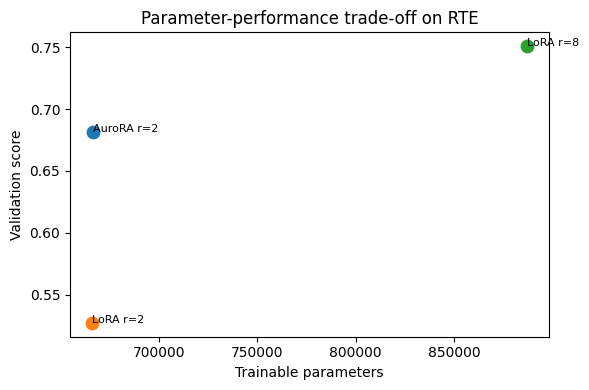

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/rte_param_vs_score.png


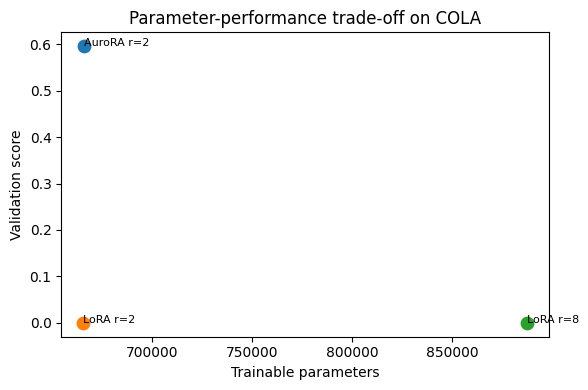

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/cola_param_vs_score.png


In [ ]:
summary = pd.read_csv(f"{PROJECT_DIR}/results/results_summary.csv")

for task_name in ["mrpc", "rte", "cola"]:
    sub = summary[summary["task"] == task_name].copy()

    plt.figure(figsize=(6, 4))

    for _, row in sub.iterrows():
        if row["method"] == "lora":
            label = f"LoRA r={int(row['rank'])}"
        else:
            if row["use_fixed"] and row["use_spline"]:
                label = f"AuroRA r={int(row['rank'])}"
            elif (not row["use_fixed"]) and row["use_spline"]:
                label = "AuroRA w/o fixed"
            elif row["use_fixed"] and (not row["use_spline"]):
                label = "AuroRA w/o spline"
            else:
                label = "AuroRA variant"

        plt.scatter(
            row["mean_trainable_params"],
            row["mean_score"],
            s=80
        )

        plt.text(
            row["mean_trainable_params"],
            row["mean_score"],
            label,
            fontsize=8
        )

    plt.xlabel("Trainable parameters")
    plt.ylabel("Validation score")
    plt.title(f"Parameter-performance trade-off on {task_name.upper()}")
    plt.tight_layout()

    fig_path = f"{PROJECT_DIR}/figures/{task_name}_param_vs_score.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)

,setting,mean_score,std_score,num_runs
3,w/o fixed,0.768791,0.003744,3
4,w/o spline,0.866013,0.007075,3
5,Full AuroRA,0.863358,0.018562,8


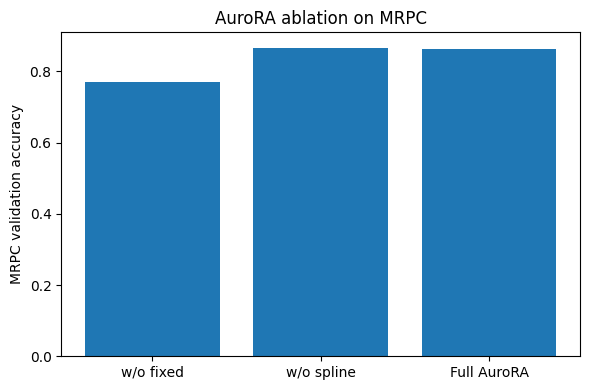

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/mrpc_ablation.png


In [ ]:
summary = pd.read_csv(f"{PROJECT_DIR}/results/results_summary.csv")

abl = summary[
    (summary["task"] == "mrpc")
    & (summary["method"] == "aurora")
    & (summary["rank"] == 2)
].copy()

def setting_name(row):
    if row["use_fixed"] and row["use_spline"]:
        return "Full AuroRA"
    elif (not row["use_fixed"]) and row["use_spline"]:
        return "w/o fixed"
    elif row["use_fixed"] and (not row["use_spline"]):
        return "w/o spline"
    else:
        return "other"

abl["setting"] = abl.apply(setting_name, axis=1)

display(abl[["setting", "mean_score", "std_score", "num_runs"]])

plt.figure(figsize=(6, 4))
plt.bar(abl["setting"], abl["mean_score"])

plt.ylabel("MRPC validation accuracy")
plt.title("AuroRA ablation on MRPC")
plt.tight_layout()

fig_path = f"{PROJECT_DIR}/figures/mrpc_ablation.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [ ]:
import platform
import transformers
import datasets
import evaluate

env_info = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "datasets": datasets.__version__,
    "evaluate": evaluate.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
}

env_path = f"{PROJECT_DIR}/results/environment_info.txt"

with open(env_path, "w") as f:
    for k, v in env_info.items():
        f.write(f"{k}: {v}\n")

print(open(env_path).read())

python: 3.12.13
torch: 2.10.0+cu128
transformers: 5.8.0
datasets: 4.8.5
evaluate: 0.4.6
cuda_available: True
gpu_name: NVIDIA L4



In [ ]:
EXPECTED = {
    "mrpc": {"epochs": 10, "lr": 8e-4, "batch_size": 32, "max_length": 256},
    "rte":  {"epochs": 15, "lr": 5e-4, "batch_size": 16, "max_length": 256},
    "cola": {"epochs": 15, "lr": 5e-3, "batch_size": 32, "max_length": 256},
}

clean_parts = []

for task, cfg in EXPECTED.items():
    sub = df[
        (df["task"] == task)
        & (df["epochs"] == cfg["epochs"])
        & (df["batch_size"] == cfg["batch_size"])
        & (df["max_length"] == cfg["max_length"])
    ].copy()

    sub = sub[abs(sub["lr"] - cfg["lr"]) < 1e-12]
    clean_parts.append(sub)

clean = pd.concat(clean_parts, ignore_index=True)

dedup_cols = [
    "task",
    "method",
    "rank",
    "seed",
    "epochs",
    "lr",
    "batch_size",
    "max_length",
    "use_fixed",
    "use_spline",
    "activation",
]

clean = clean.drop_duplicates(
    subset=dedup_cols,
    keep="last"
)

clean_path = f"{PROJECT_DIR}/results/results_clean.csv"
clean.to_csv(clean_path, index=False)

print("Clean results saved to:", clean_path)
print("Clean results 行数：", len(clean))

display(clean.sort_values(["task", "method", "rank", "use_fixed", "use_spline", "seed"]))

Clean results saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_clean.csv
Clean results 行数： 33


,task,method,rank,seed,epochs,lr,batch_size,max_length,alpha,dropout,...,replaced_layers,trainable_params,total_params,trainable_percent,time_min,eval_loss,eval_accuracy,eval_f1,eval_main_score,eval_matthews_correlation
29,cola,aurora,2,0,15,0.0050,32,256,4,0.0,...,24,666338,124721378,0.534261,11.633017,0.510448,NaN,NaN,0.600697,0.600697
34,cola,aurora,2,1,15,0.0050,32,256,4,0.0,...,24,666338,124721378,0.534261,11.651677,0.485337,NaN,NaN,0.600624,0.600624
35,cola,aurora,2,2,15,0.0050,32,256,4,0.0,...,24,666338,124721378,0.534261,11.644311,0.506677,NaN,NaN,0.585706,0.585706
27,cola,lora,2,0,15,0.0050,32,256,4,0.0,...,24,665858,124720898,0.533878,11.210559,0.618524,NaN,NaN,0.000000,0.000000
30,cola,lora,2,1,15,0.0050,32,256,4,0.0,...,24,665858,124720898,0.533878,11.210940,0.619241,NaN,NaN,0.000000,0.000000
31,cola,lora,2,2,15,0.0050,32,256,4,0.0,...,24,665858,124720898,0.533878,11.207162,0.618579,NaN,NaN,0.000000,0.000000
28,cola,lora,8,0,15,0.0050,32,256,4,0.0,...,24,887042,124942082,0.709963,11.221534,0.618301,NaN,NaN,0.000000,0.000000
32,cola,lora,8,1,15,0.0050,32,256,4,0.0,...,24,887042,124942082,0.709963,11.225447,0.618720,NaN,NaN,0.000000,0.000000
33,cola,lora,8,2,15,0.0050,32,256,4,0.0,...,24,887042,124942082,0.709963,11.224927,0.618538,NaN,NaN,0.000000,0.000000
12,mrpc,aurora,2,0,10,0.0008,32,256,4,0.0,...,24,666338,124721378,0.534261,3.312535,0.429419,0.772059,0.847291,0.772059,NaN


In [ ]:
clean_summary = (
    clean.groupby([
        "task",
        "method",
        "rank",
        "use_fixed",
        "use_spline",
        "activation"
    ])
    .agg(
        mean_score=("eval_main_score", "mean"),
        std_score=("eval_main_score", "std"),
        mean_trainable_params=("trainable_params", "mean"),
        mean_trainable_percent=("trainable_percent", "mean"),
        mean_time_min=("time_min", "mean"),
        num_runs=("eval_main_score", "count")
    )
    .reset_index()
)

clean_summary_path = f"{PROJECT_DIR}/results/results_summary_clean.csv"
clean_summary.to_csv(clean_summary_path, index=False)

print("Clean summary saved to:", clean_summary_path)
display(clean_summary)

Clean summary saved to: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/results/results_summary_clean.csv


,task,method,rank,use_fixed,use_spline,activation,mean_score,std_score,mean_trainable_params,mean_trainable_percent,mean_time_min,num_runs
0,cola,aurora,2,True,True,tanh,0.595676,0.008634,666338.0,0.534261,11.643002,3
1,cola,lora,2,False,False,tanh,0.000000,0.000000,665858.0,0.533878,11.209554,3
2,cola,lora,8,False,False,tanh,0.000000,0.000000,887042.0,0.709963,11.223969,3
3,mrpc,aurora,2,False,True,tanh,0.768791,0.003744,666338.0,0.534261,3.310989,3
4,mrpc,aurora,2,True,False,tanh,0.866013,0.007075,666338.0,0.534261,3.260218,3
5,mrpc,aurora,2,True,True,tanh,0.868464,0.003744,666338.0,0.534261,3.349311,3
6,mrpc,lora,2,False,False,tanh,0.868464,0.012577,665858.0,0.533878,3.209787,3
7,mrpc,lora,8,False,False,tanh,0.883170,0.007488,887042.0,0.709963,3.232170,3
8,rte,aurora,2,True,True,tanh,0.681107,0.036875,666338.0,0.534261,3.680390,3
9,rte,lora,2,False,False,tanh,0.527076,0.093793,665858.0,0.533878,3.074461,3


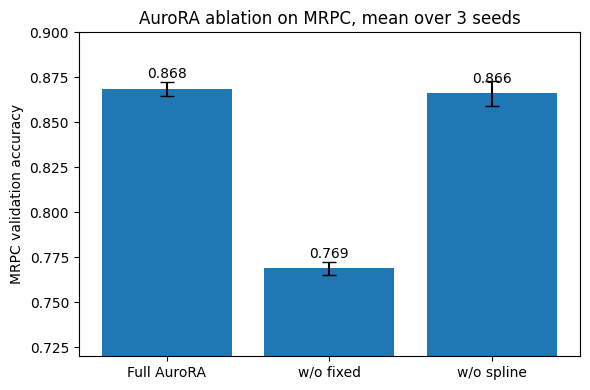

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/mrpc_ablation_clean_with_errorbar.png


,setting,mean_score,std_score,num_runs
5,Full AuroRA,0.868464,0.003744,3
3,w/o fixed,0.768791,0.003744,3
4,w/o spline,0.866013,0.007075,3


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv(f"{PROJECT_DIR}/results/results_summary_clean.csv")

abl = summary[
    (summary["task"] == "mrpc")
    & (summary["method"] == "aurora")
    & (summary["rank"] == 2)
].copy()

def setting_name(row):
    if row["use_fixed"] and row["use_spline"]:
        return "Full AuroRA"
    elif (not row["use_fixed"]) and row["use_spline"]:
        return "w/o fixed"
    elif row["use_fixed"] and (not row["use_spline"]):
        return "w/o spline"
    else:
        return "other"

abl["setting"] = abl.apply(setting_name, axis=1)

order = ["Full AuroRA", "w/o fixed", "w/o spline"]
abl["setting"] = pd.Categorical(abl["setting"], categories=order, ordered=True)
abl = abl.sort_values("setting")

plt.figure(figsize=(6, 4))

plt.bar(
    abl["setting"],
    abl["mean_score"],
    yerr=abl["std_score"],
    capsize=5
)

for i, row in enumerate(abl.itertuples()):
    plt.text(
        i,
        row.mean_score + 0.006,
        f"{row.mean_score:.3f}",
        ha="center",
        fontsize=10
    )

plt.ylim(0.72, 0.90)
plt.ylabel("MRPC validation accuracy")
plt.title("AuroRA ablation on MRPC, mean over 3 seeds")
plt.tight_layout()

fig_path = f"{PROJECT_DIR}/figures/mrpc_ablation_clean_with_errorbar.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)
display(abl[["setting", "mean_score", "std_score", "num_runs"]])

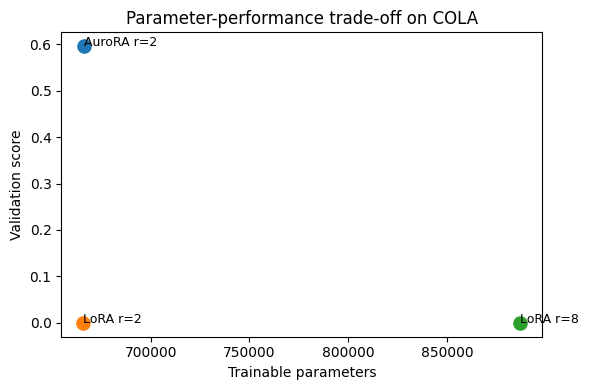

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/cola_param_vs_score_clean.png


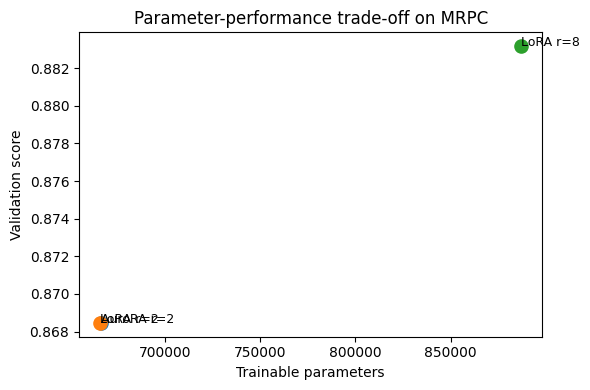

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/mrpc_param_vs_score_clean.png


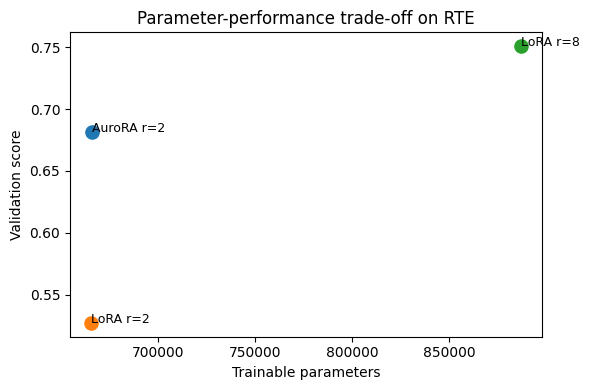

Saved: /content/drive/MyDrive/COMP6258_AuroRA_Reproduction/figures/rte_param_vs_score_clean.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv(f"{PROJECT_DIR}/results/results_summary_clean.csv")

for task_name in ["cola", "mrpc", "rte"]:
    sub = summary[summary["task"] == task_name].copy()

    main = sub[
        ((sub["method"] == "lora") & (sub["rank"].isin([2, 8]))) |
        ((sub["method"] == "aurora") & (sub["use_fixed"] == True) & (sub["use_spline"] == True))
    ].copy()

    plt.figure(figsize=(6, 4))

    for _, row in main.iterrows():
        if row["method"] == "lora":
            label = f"LoRA r={int(row['rank'])}"
        else:
            label = f"AuroRA r={int(row['rank'])}"

        plt.scatter(
            row["mean_trainable_params"],
            row["mean_score"],
            s=90
        )

        plt.text(
            row["mean_trainable_params"],
            row["mean_score"],
            label,
            fontsize=9
        )

    plt.xlabel("Trainable parameters")
    plt.ylabel("Validation score")
    plt.title(f"Parameter-performance trade-off on {task_name.upper()}")
    plt.tight_layout()

    fig_path = f"{PROJECT_DIR}/figures/{task_name}_param_vs_score_clean.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)